# Business Insights & Bankruptcy Risk Analysis

This notebook translates machine learning results into actionable business insights.

Objectives:

- Identify the most important bankruptcy indicators
- Analyze financial patterns among bankrupt firms
- Rank companies by bankruptcy risk
- Create risk segments for decision-making

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

%matplotlib inline

# Load Dataset

In [2]:
df = pd.read_csv(
    "../data/bankruptcy_processed.csv"
)

print(df.shape)

df.head()

(43405, 26)


,A27,A24,A42,A41,A26,A22,A13,A16,A46,A15,A23,A39,A19,A35,A6,A45,A12,A25,A18,A38,A11,A14,A7,A1,A51,Bankrupt
0,1.45820,0.47706,0.128040,0.051402,0.60411,0.21402,0.166600,0.73378,1.52250,497.42,0.119980,0.128040,0.149420,0.21402,0.38825,1.00970,0.65980,0.50494,0.249760,0.50591,0.249760,0.249760,0.249760,0.200550,0.37854,0.0
1,88.44400,0.15510,0.145950,0.064371,0.43992,0.24806,0.158350,0.53838,1.12520,677.96,0.123040,0.121300,0.152000,0.20616,0.00000,0.51045,0.51680,0.39542,0.258340,0.49788,0.261140,0.258340,0.258340,0.209120,0.49988,0.0
2,86.01100,0.15510,0.231170,0.074020,0.37282,0.30260,0.244350,0.45961,1.01010,794.16,0.189960,0.241140,0.236100,0.31565,0.00000,0.94807,0.64184,0.28932,0.309060,0.51537,0.312580,0.309060,0.309060,0.248660,0.48152,0.0
3,0.94076,0.17193,0.088995,0.069622,0.36152,0.11550,0.094257,0.39803,1.56960,917.01,0.062782,0.088995,0.071428,0.11550,0.14988,0.28720,0.30163,0.57353,0.092704,0.57353,0.092704,0.092704,0.092704,0.081483,0.30734,0.0
4,1.41380,0.18732,0.122310,0.096680,0.32211,0.19832,0.121820,0.32211,0.95787,1133.20,0.115530,0.122310,0.115530,0.19832,0.18732,0.73919,0.33147,0.38677,0.187320,0.43489,0.187320,0.187320,0.187320,0.187320,0.56511,0.0


# Load Tuned Model

In [3]:
model = joblib.load(
    "../models/random_forest_tuned.pkl"
)

print(model)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=500, n_jobs=-1, random_state=42)


# Split Features / Target

In [4]:
X = df.drop(
    columns=["Bankrupt"]
)

y = df["Bankrupt"]

# Feature Importance

In [5]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df.head(20)

,Feature,Importance
0,A27,0.140933
1,A24,0.093404
2,A46,0.060975
3,A26,0.058562
4,A6,0.049332
5,A13,0.047885
6,A16,0.046787
7,A35,0.039467
8,A39,0.039350
9,A25,0.038262


# Top 20 Feature Importance Plot

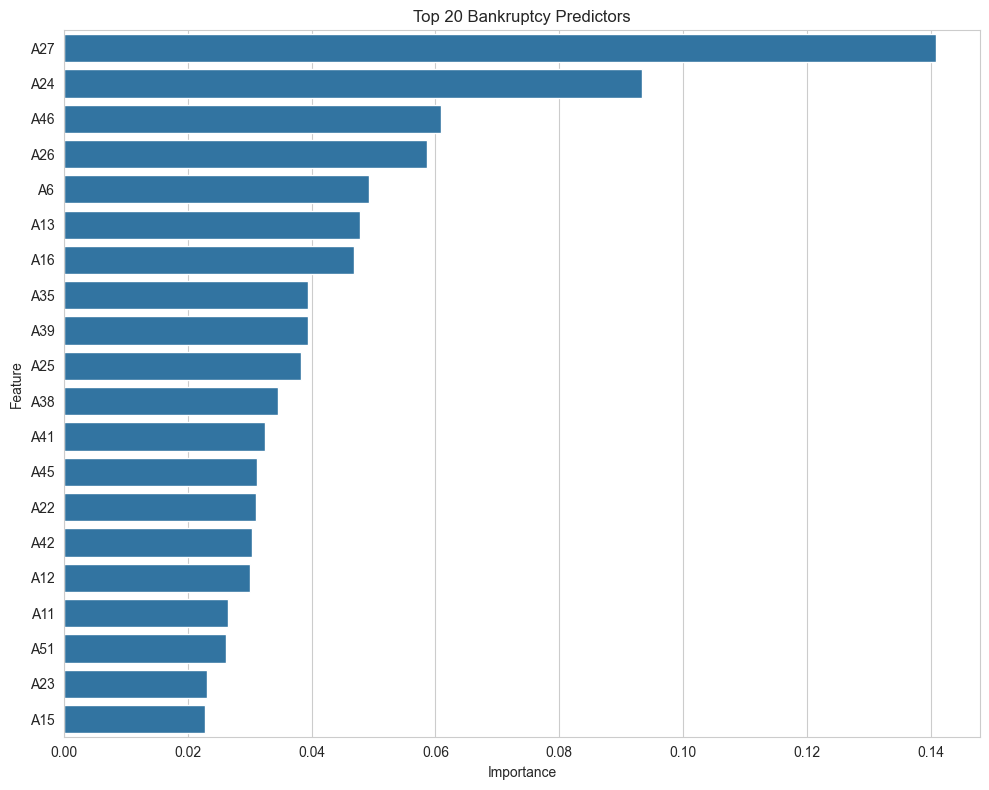

In [6]:
plt.figure(
    figsize=(10, 8)
)

sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Bankruptcy Predictors"
)

plt.tight_layout()

plt.show()

# Top 10 Predictors Table

In [7]:
top10 = importance_df.head(10)

top10

,Feature,Importance
0,A27,0.140933
1,A24,0.093404
2,A46,0.060975
3,A26,0.058562
4,A6,0.049332
5,A13,0.047885
6,A16,0.046787
7,A35,0.039467
8,A39,0.039350
9,A25,0.038262


# Correlation With Bankruptcy

In [8]:
corr = (
    df.corr(numeric_only=True)["Bankrupt"]
    .drop("Bankrupt")
    .sort_values()
)

corr.tail(10)

A6    -0.108085
A16   -0.072977
A12   -0.072862
A26   -0.072840
A45   -0.041998
A46   -0.040730
A41   -0.024799
A27   -0.022541
A15    0.000976
A51    0.142418
Name: Bankrupt, dtype: float64

# Positive Correlations

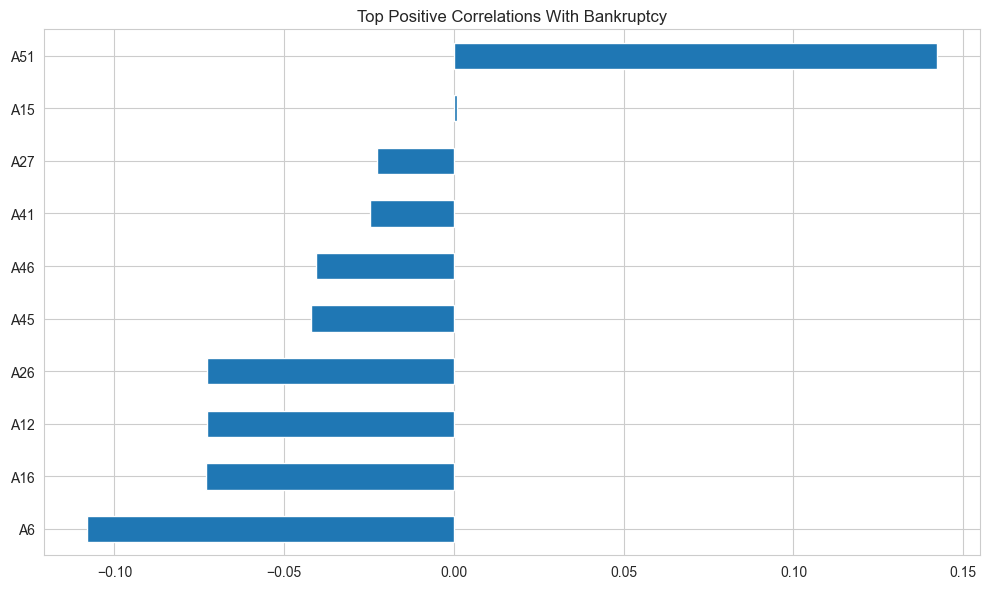

In [9]:
plt.figure(
    figsize=(10, 6)
)

corr.tail(10).plot(
    kind="barh"
)

plt.title(
    "Top Positive Correlations With Bankruptcy"
)

plt.tight_layout()

plt.show()

# Negative Correlations

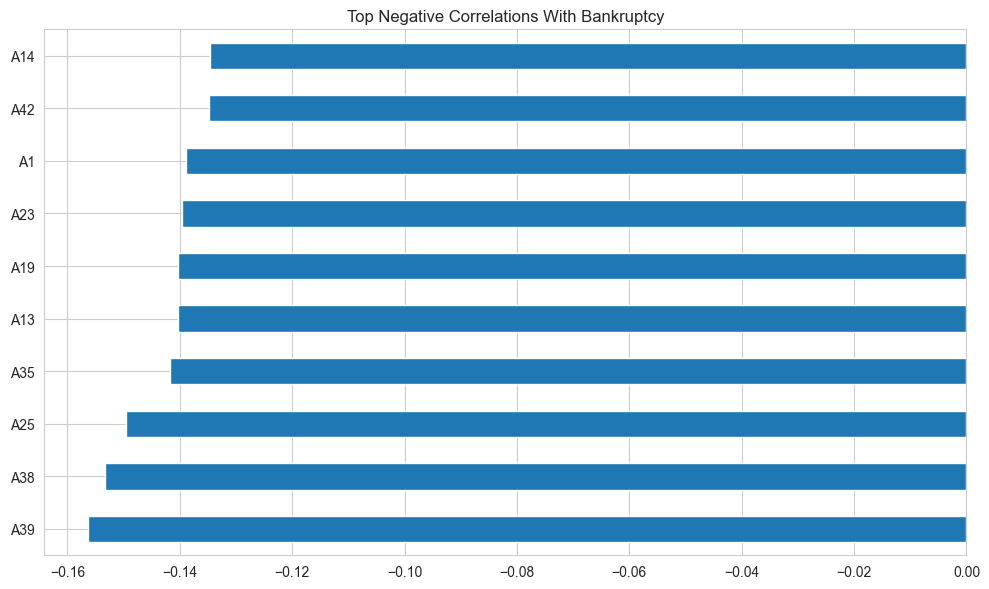

In [10]:
plt.figure(
    figsize=(10, 6)
)

corr.head(10).plot(
    kind="barh"
)

plt.title(
    "Top Negative Correlations With Bankruptcy"
)

plt.tight_layout()

plt.show()

# Estimate risk scores

In [11]:
df["Bankruptcy_Probability"] = (
    model.predict_proba(X)[:, 1]
)

df[
    ["Bankruptcy_Probability"]
].head()

,Bankruptcy_Probability
0,0.006241
1,0.089291
2,0.074379
3,0.003038
4,0.049888


# Probability Distribution

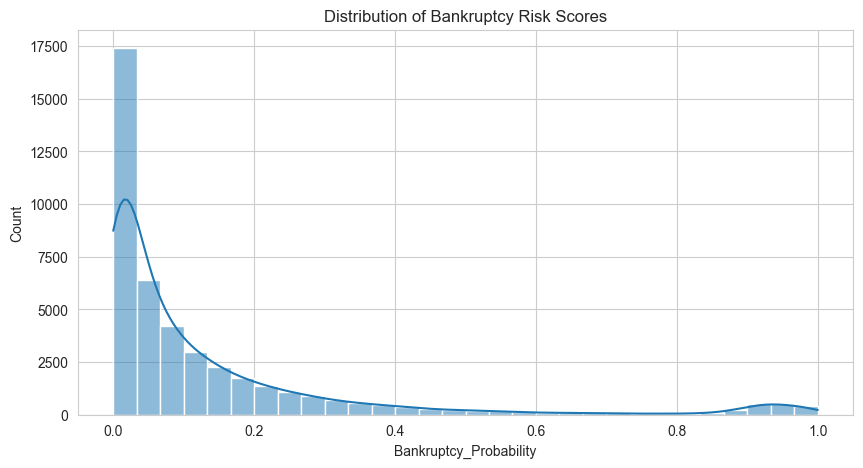

In [12]:
plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    df["Bankruptcy_Probability"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Bankruptcy Risk Scores"
)

plt.show()

# Create Risk Segments

In [13]:
df["Risk_Level"] = pd.cut(
    df["Bankruptcy_Probability"],
    bins=[
        0,
        0.30,
        0.70,
        1.00
    ],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

# Risk Segment Counts

In [14]:
df["Risk_Level"].value_counts()

Risk_Level
Low Risk       36701
Medium Risk     3191
High Risk       1913
Name: count, dtype: int64

# Risk Segment Visualization

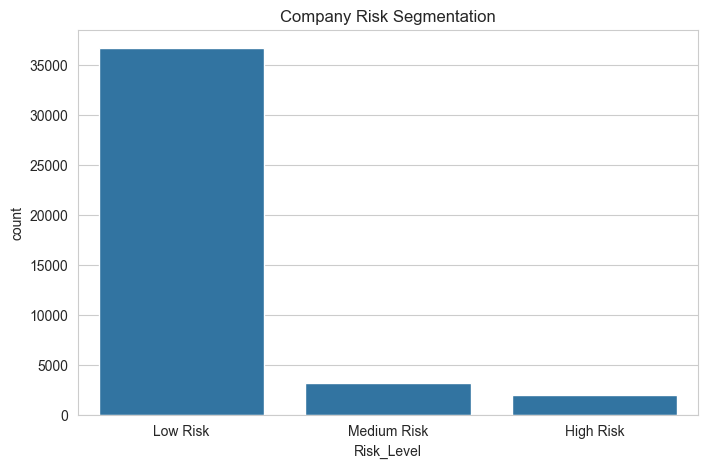

In [15]:
plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    x="Risk_Level",
    data=df,
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title(
    "Company Risk Segmentation"
)

plt.show()

# Highest Risk Companies

In [16]:
high_risk = (
    df.sort_values(
        "Bankruptcy_Probability",
        ascending=False
    )
    .head(20)
)

high_risk[
    [
        "Bankruptcy_Probability",
        "Risk_Level"
    ]
]

,Bankruptcy_Probability,Risk_Level
27554,0.999946,High Risk
43140,0.999704,High Risk
16993,0.998705,High Risk
27460,0.998598,High Risk
37267,0.998381,High Risk
43150,0.998256,High Risk
37337,0.998242,High Risk
27483,0.998241,High Risk
37294,0.998135,High Risk
27663,0.998135,High Risk


# Compare Risk Scores By Actual Class

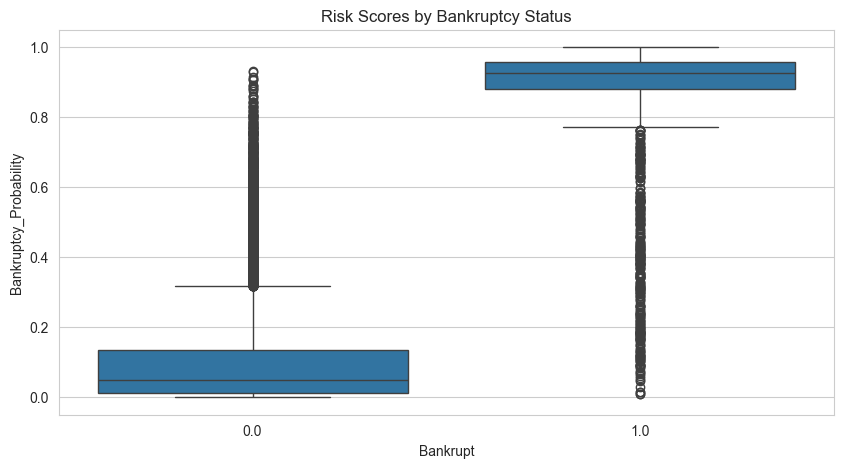

In [17]:
plt.figure(
    figsize=(10, 5)
)

sns.boxplot(
    x="Bankrupt",
    y="Bankruptcy_Probability",
    data=df
)

plt.title(
    "Risk Scores by Bankruptcy Status"
)

plt.show()

# Business Insight Summary

In [18]:
summary = pd.DataFrame({
    "Metric": [
        "Total Companies",
        "Bankrupt Companies",
        "Average Risk Score",
        "High Risk Companies"
    ],
    "Value": [
        len(df),
        int(df["Bankrupt"].sum()),
        round(df["Bankruptcy_Probability"].mean(), 3),
        int(
            (
                df["Risk_Level"]
                == "High Risk"
            ).sum()
        )
    ]
})

summary

,Metric,Value
0,Total Companies,43405.000
1,Bankrupt Companies,2091.000
2,Average Risk Score,0.133
3,High Risk Companies,1913.000


# Save Insights Dataset

In [19]:
df.to_csv(
    "../data/bankruptcy_risk_scored.csv",
    index=False
)

print(
    "Saved bankruptcy_risk_scored.csv"
)

Saved bankruptcy_risk_scored.csv


In [20]:
importance_df.head(10)

,Feature,Importance
0,A27,0.140933
1,A24,0.093404
2,A46,0.060975
3,A26,0.058562
4,A6,0.049332
5,A13,0.047885
6,A16,0.046787
7,A35,0.039467
8,A39,0.039350
9,A25,0.038262


In [21]:
df["Risk_Level"].value_counts()

Risk_Level
Low Risk       36701
Medium Risk     3191
High Risk       1913
Name: count, dtype: int64